# Word2Vec (1/3): Intuición — “El contexto crea significado”

Este notebook construye la intuición detrás de **Word2Vec**: cómo el **contexto** de una palabra puede usarse para capturar significado, y por qué eso nos lleva naturalmente a **embeddings densos**.

## Objetivos
Al finalizar, podrás:
- Explicar por qué **one-hot** no captura similitud semántica.
- Construir **ventanas de contexto** a partir de texto.
- Crear una **matriz de co-ocurrencias** (conteo de contextos).
- Explorar similitud con **cosine similarity**.
- Ver la idea de “espacio semántico” con una proyección (SVD/PCA).
- Conectar esto con CBOW y Skip-gram (Word2Vec).

> Nota: aquí **no entrenamos Word2Vec** todavía. Eso será en el Notebook 2 (embeddings “a mano”) y Notebook 3 (paquetes).


## 0. Setup (spaCy + utilidades)

Usaremos **spaCy** para tokenizar (Opción B).  
Si no tienes el modelo en español, ejecuta (una sola vez) en tu entorno:

```bash
python -m spacy download es_core_news_sm
```

Si estás en inglés, puedes usar `en_core_web_sm` y cambiar el nombre del modelo en el código.


In [1]:
from __future__ import annotations

import math
from collections import Counter
from dataclasses import dataclass
from typing import Dict, List, Sequence, Tuple

import numpy as np
import matplotlib.pyplot as plt

import spacy


In [2]:
def load_spacy_model(preferred: str = "es_core_news_sm"):
    # Load a spaCy pipeline if available; otherwise fallback to a blank tokenizer.
    # This keeps the notebook runnable even if the language model is not installed.
    try:
        return spacy.load(preferred)
    except Exception:
        lang = preferred.split("_")[0] if "_" in preferred else "es"
        print(
            f"[WARN] Could not load '{preferred}'. Falling back to spacy.blank('{lang}').\n"
            f"       To install the model: python -m spacy download {preferred}"
        )
        return spacy.blank(lang)


nlp = load_spacy_model("es_core_news_sm")


## 1. Por qué one-hot no sirve para “similitud”

En one-hot, cada palabra es un vector con un único 1 y el resto 0.  
Eso significa que **todas las palabras están igual de lejos** entre sí (en términos de dot product), sin importar su significado.


In [3]:
# Vocabulario juguete
vocab = ["gato", "perro", "leche", "agua"]
idx = {w: i for i, w in enumerate(vocab)}


def one_hot(word: str, vocab_index: Dict[str, int]) -> np.ndarray:
    v = np.zeros(len(vocab_index), dtype=float)
    v[vocab_index[word]] = 1.0
    return v


# Dot products
for a in vocab:
    for b in vocab:
        dp = float(one_hot(a, idx) @ one_hot(b, idx))
        if a != b and dp != 0.0:
            raise RuntimeError("Unexpected result for one-hot.")
print("One-hot dot product between different words is always 0.")


One-hot dot product between different words is always 0.


En contraste, lo que queremos es que palabras como **“gato”** y **“perro”** terminen “cerca”, porque aparecen en contextos parecidos.

Esto nos lleva a la hipótesis distribucional:

> **Las palabras que aparecen en contextos similares tienden a tener significados similares.**


## 2. Un mini-corpus para jugar con contexto

Usaremos un corpus pequeño diseñado para tener regularidades:
- “rey / reina” asociados a “hombre / mujer” y “gobierna / reino”
- “príncipe / princesa” con patrones parecidos
- y algunas frases neutras (“trabaja”, “vive”, etc.)

En el Notebook 2, verás cómo esto permite que analogías como **rey − hombre + mujer ≈ reina** emerjan.


In [4]:
corpus_sentences = [
    "El rey es un hombre.",
    "La reina es una mujer.",
    "El rey gobierna el reino.",
    "La reina gobierna el reino.",
    "El príncipe es un hombre.",
    "La princesa es una mujer.",
    "El príncipe vive en el reino.",
    "La princesa vive en el reino.",
    "El hombre trabaja.",
    "La mujer trabaja.",
    "El rey y la reina viven en el palacio.",
    "El príncipe y la princesa viven en el palacio.",
]

print("\n".join(corpus_sentences[:4]))


El rey es un hombre.
La reina es una mujer.
El rey gobierna el reino.
La reina gobierna el reino.


## 3. Tokenización con spaCy

Normalizaremos:
- minúsculas
- quitaremos puntuación y espacios
- (opcional) quitar stopwords: en este notebook **NO** las quitamos por defecto para mantener la lectura intuitiva.

> En producción, la estrategia de limpieza depende del objetivo.


In [5]:
def tokenize_sentences(sentences: Sequence[str], nlp_obj, *, remove_stop: bool = False) -> List[List[str]]:
    tokenized: List[List[str]] = []
    for s in sentences:
        doc = nlp_obj(s)
        toks: List[str] = []
        for t in doc:
            if t.is_space or t.is_punct:
                continue
            if remove_stop and t.is_stop:
                continue
            toks.append(t.text.lower())
        tokenized.append(toks)
    return tokenized


tokenized = tokenize_sentences(corpus_sentences, nlp, remove_stop=False)
tokenized[:3]


[['el', 'rey', 'es', 'un', 'hombre'],
 ['la', 'reina', 'es', 'una', 'mujer'],
 ['el', 'rey', 'gobierna', 'el', 'reino']]

## 4. Ventanas de contexto

Definimos una ventana de tamaño `c` alrededor de cada palabra central.

Esta operación es la base de:
- **CBOW:** contexto → predice palabra central
- **Skip-gram:** palabra central → predice contexto


In [6]:
@dataclass(frozen=True)
class ContextPair:
    center: str
    context: str


def generate_skipgram_pairs(tokenized_sents: Sequence[Sequence[str]], window: int) -> List[ContextPair]:
    pairs: List[ContextPair] = []
    for sent in tokenized_sents:
        n = len(sent)
        for i, w_center in enumerate(sent):
            left = max(0, i - window)
            right = min(n, i + window + 1)
            for j in range(left, right):
                if j == i:
                    continue
                pairs.append(ContextPair(center=w_center, context=sent[j]))
    return pairs


pairs = generate_skipgram_pairs(tokenized, window=2)
pairs[:10], len(pairs)


([ContextPair(center='el', context='rey'),
  ContextPair(center='el', context='es'),
  ContextPair(center='rey', context='el'),
  ContextPair(center='rey', context='es'),
  ContextPair(center='rey', context='un'),
  ContextPair(center='es', context='el'),
  ContextPair(center='es', context='rey'),
  ContextPair(center='es', context='un'),
  ContextPair(center='es', context='hombre'),
  ContextPair(center='un', context='rey')],
 192)

## 5. Matriz de co-ocurrencias (conteo)

Construimos una matriz `C` tal que:
- filas = palabra central
- columnas = palabra de contexto
- `C[i, j]` = cuántas veces la palabra `j` aparece en el contexto de la palabra `i`.

Esto es un enfoque “count-based”. Word2Vec es “predictive-based”, pero **la intuición es exactamente la misma: contexto**.


In [7]:
def build_vocabulary(tokenized_sents: Sequence[Sequence[str]], min_freq: int = 1) -> List[str]:
    counts = Counter(w for sent in tokenized_sents for w in sent)
    vocab = [w for w, c in counts.items() if c >= min_freq]
    vocab.sort()
    return vocab


def build_cooccurrence_matrix(pairs: Sequence[ContextPair], vocab: Sequence[str]) -> np.ndarray:
    vocab_index = {w: i for i, w in enumerate(vocab)}
    mat = np.zeros((len(vocab), len(vocab)), dtype=np.float64)
    for p in pairs:
        if p.center in vocab_index and p.context in vocab_index:
            mat[vocab_index[p.center], vocab_index[p.context]] += 1.0
    return mat


vocab = build_vocabulary(tokenized, min_freq=1)
C = build_cooccurrence_matrix(pairs, vocab=vocab)

print(f"Vocabulary size: {len(vocab)}")
vocab[:20]


Vocabulary size: 19


['el',
 'en',
 'es',
 'gobierna',
 'hombre',
 'la',
 'mujer',
 'palacio',
 'princesa',
 'príncipe',
 'reina',
 'reino',
 'rey',
 'trabaja',
 'un',
 'una',
 'vive',
 'viven',
 'y']

In [8]:
def show_top_contexts(word: str, Cmat: np.ndarray, vocab: Sequence[str], top_k: int = 10) -> List[Tuple[str, float]]:
    vi = {w: i for i, w in enumerate(vocab)}
    if word not in vi:
        raise KeyError(f"'{word}' not in vocabulary.")
    row = Cmat[vi[word]]
    top_idx = np.argsort(-row)[:top_k]
    return [(vocab[j], float(row[j])) for j in top_idx if row[j] > 0]


for w in ["rey", "reina", "hombre", "mujer", "reino", "palacio"]:
    print(w, "→", show_top_contexts(w, C, vocab, top_k=8))


rey → [('el', 4.0), ('un', 1.0), ('la', 1.0), ('y', 1.0), ('es', 1.0), ('gobierna', 1.0)]
reina → [('la', 3.0), ('el', 1.0), ('una', 1.0), ('viven', 1.0), ('y', 1.0), ('gobierna', 1.0), ('es', 1.0), ('en', 1.0)]
hombre → [('es', 2.0), ('un', 2.0), ('el', 1.0), ('trabaja', 1.0)]
mujer → [('es', 2.0), ('una', 2.0), ('la', 1.0), ('trabaja', 1.0)]
reino → [('el', 4.0), ('en', 2.0), ('gobierna', 2.0)]
palacio → [('el', 2.0), ('en', 2.0)]


## 6. De conteos a “señal”: PPMI

Los conteos crudos están dominados por palabras frecuentes. Un truco clásico es usar **PPMI** (Positive PMI):

PMI(w,c) = log( P(w,c) / (P(w) P(c)) ), y PPMI = max(PMI, 0)

PPMI resalta asociaciones **más informativas**.


In [9]:
def ppmi_matrix(Cmat: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    total = Cmat.sum()
    if total <= 0:
        raise ValueError("Co-occurrence matrix is empty.")

    Pw = Cmat.sum(axis=1, keepdims=True) / total
    Pc = Cmat.sum(axis=0, keepdims=True) / total
    Pwc = Cmat / total

    pmi = np.log((Pwc + eps) / (Pw @ Pc + eps))
    ppmi = np.maximum(pmi, 0.0)
    return ppmi


PPMI = ppmi_matrix(C)
PPMI.shape


(19, 19)

## 7. Embeddings densos (count-based) con SVD

Una forma simple de obtener embeddings densos:
1) Construye PPMI
2) Aplica SVD y toma las primeras `d` dimensiones

Esto **no es Word2Vec**, pero muestra que “contexto → vectores” ya produce estructura semántica.


In [10]:
def svd_embeddings(M: np.ndarray, dim: int = 2) -> np.ndarray:
    # Full SVD is fine for small matrices; for large corpora, use truncated SVD.
    U, S, _Vt = np.linalg.svd(M, full_matrices=False)
    E = U[:, :dim] * np.sqrt(S[:dim])
    return E


E2 = svd_embeddings(PPMI, dim=2)
E2[:5]


array([[-0.43505462,  0.66048279],
       [-0.39611201,  0.78024831],
       [-0.83002806, -0.53545502],
       [-0.320213  ,  0.49433803],
       [-0.73756245, -0.62481402]])

In [11]:
def cosine_similarity(a: np.ndarray, b: np.ndarray, eps: float = 1e-12) -> float:
    denom = (np.linalg.norm(a) * np.linalg.norm(b)) + eps
    return float((a @ b) / denom)


def most_similar(word: str, E: np.ndarray, vocab: Sequence[str], top_k: int = 8) -> List[Tuple[str, float]]:
    vi = {w: i for i, w in enumerate(vocab)}
    if word not in vi:
        raise KeyError(f"'{word}' not in vocabulary.")
    i = vi[word]
    sims: List[Tuple[str, float]] = []
    for j, w in enumerate(vocab):
        if j == i:
            continue
        sims.append((w, cosine_similarity(E[i], E[j])))
    sims.sort(key=lambda x: x[1], reverse=True)
    return sims[:top_k]


for w in ["rey", "reina", "hombre", "mujer", "príncipe", "princesa", "reino", "palacio"]:
    print(w, "→", most_similar(w, E2, vocab, top_k=6))


rey → [('príncipe', 0.9999604792496488), ('reina', 0.9990660322391363), ('la', 0.9950871393073546), ('princesa', 0.9850525080435482), ('y', 0.9758201451802913), ('viven', 0.9070532793654145)]
reina → [('príncipe', 0.9994107001259538), ('rey', 0.9990660322391363), ('princesa', 0.9915755291493541), ('la', 0.9898798891358139), ('y', 0.9843532843263311), ('viven', 0.924398016686246)]
hombre → [('es', 0.9915746601505565), ('mujer', 0.990897530326257), ('trabaja', 0.9907055711110943), ('un', 0.9855438947524212), ('una', 0.9452487341705426), ('la', 0.4930394181616094)]
mujer → [('trabaja', 0.9999989938619287), ('es', 0.9999868582191096), ('un', 0.9993800800635759), ('hombre', 0.990897530326257), ('una', 0.9805774204309199), ('la', 0.6056703939876854)]
príncipe → [('rey', 0.9999604792496488), ('reina', 0.9994107001259538), ('la', 0.9941676328530655), ('princesa', 0.986544994934575), ('y', 0.9777248083150556), ('viven', 0.9107604482659134)]
princesa → [('y', 0.998884578350741), ('reina', 0.9915

## 8. Visualización 2D del “espacio semántico”

Ojo: es un corpus minúsculo, así que esto es solo ilustrativo.


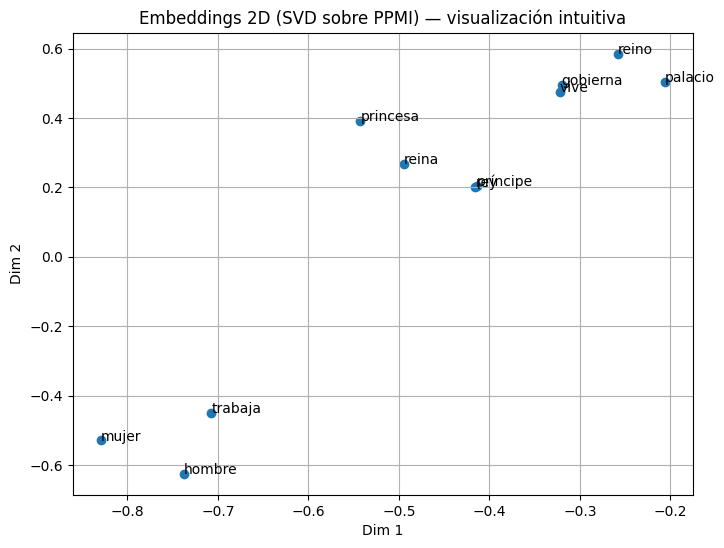

In [12]:
def plot_embeddings_2d(E: np.ndarray, vocab: Sequence[str], words: Sequence[str]) -> None:
    vi = {w: i for i, w in enumerate(vocab)}
    xs, ys, labs = [], [], []
    for w in words:
        if w not in vi:
            continue
        xs.append(E[vi[w], 0])
        ys.append(E[vi[w], 1])
        labs.append(w)

    plt.figure(figsize=(8, 6))
    plt.scatter(xs, ys)
    for x, y, lab in zip(xs, ys, labs):
        plt.text(x, y, lab, fontsize=10)
    plt.title("Embeddings 2D (SVD sobre PPMI) — visualización intuitiva")
    plt.xlabel("Dim 1")
    plt.ylabel("Dim 2")
    plt.grid(True)
    plt.show()


words_to_plot = ["rey", "reina", "hombre", "mujer", "príncipe", "princesa", "reino", "palacio", "gobierna", "vive", "trabaja"]
plot_embeddings_2d(E2, vocab, words_to_plot)


## 9. Conectando con Word2Vec: CBOW vs Skip-gram

Hasta aquí:
- “contexto” se capturó mediante conteos → PPMI → SVD
- obtuvimos vectores con estructura semántica

**Word2Vec** llega al mismo tipo de representación, pero en vez de factorizar una matriz,
entrena una red neuronal para optimizar un objetivo predictivo.

### CBOW
- Entrada: palabras del contexto
- Salida: palabra central

### Skip-gram
- Entrada: palabra central
- Salida: palabras del contexto

En el siguiente notebook (2/3) implementaremos **Skip-gram con Negative Sampling** “a mano”.


## 10. Ejercicios cortos

1) Cambia `window=1` y `window=3`. ¿Qué pasa con los vecinos más similares?  
2) Activa `remove_stop=True`. ¿Se vuelve “más semántico” o pierdes estructura útil?  
3) Agrega frases nuevas al corpus (p.ej. “El rey visita el palacio”). ¿Cómo cambia `most_similar("rey")`?  
4) (Reto) Construye co-ocurrencias con **ventana ponderada** (más peso a palabras cercanas).
